In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import scipy

from InSitu14CO import Propagator
import Functions_14CO as F

from tqdm import tqdm

from time import time

from scipy.interpolate import interp1d

from Firn_Model import Accumulation_Site

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '14' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [4]:
def smooth_diff(f):
    return np.concatenate(( [(f[1]-f[0])], (f[2:]-f[:-2])/2, [(f[-1]-f[-2])] ), axis=0)

def efilter(x, lambd): # x cannot grow or decay faster than an exponential rate
    
    for i in range(1,len(x)):
        if x[i]/x[i-1] > np.exp(1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(1/lambd[i-1])
        elif x[i]/x[i-1] < np.exp(-1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(-1/lambd[i-1])
    return x

def cum_mat_prod(A,N):
    # A can have any shape, as long as the last 2 axes are square
    A_cum = np.ones((N,*A.shape))
    A_cum[0] = np.identity(A.shape[-1])
    for i in tqdm(range(1,N)):
        A_cum[i] = A @ A_cum[i-1]
    return A_cum

In [2]:
runMat = scipy.io.loadmat('matlab/Firn Ice Model/Firn Model - CIC Forward Model v5.0/Runs/Run2026-07-21_10h18m.mat')
runMat

NameError: name 'scipy' is not defined

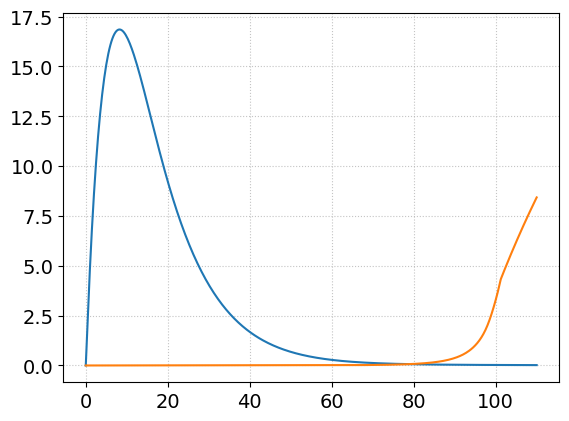

In [6]:
plt.plot(runMat['z'], runMat['C14_grains'][:,-1,1])
plt.plot(runMat['z'], runMat['C14_closed'][:,-1,1])

In [1]:
#COS_partition = np.array(
#    [#CO2         CO          CH4
#    [0.686307104, 0.31125305, 0.002439846], # neutron
#    [0.686307104, 0.31125305, 0.002439846], # neg muon
#    [0.686307104, 0.31125305, 0.002439846], # fast muon
#])
COS_partition = runMat['COS_partition']

#L = np.array([1, 7e-4])
L = np.array([1,runMat['leakage'][0,0]['closed'][0,1]])
Res = runMat['Res_partition'][0]

#f_factors = np.array([1., 0.06, 0.08])
#P0_tuning = f_factors / np.array([1, COS_partition[0,1], COS_partition[0,1]]) * COS_partition[0,1]
P0_tuning = runMat['P0_tuning'][0] * COS_partition[0,1]
f_factors = P0_tuning * np.array([1/COS_partition[0,1], 1, 1])

NameError: name 'runMat' is not defined

In [ ]:
#Dome_C = Accumulation_Site(t_resol=10)
Dome_C = Accumulation_Site(z_end=runMat['z_end'][0,0],
                           t_end=runMat['t_end'][0,0],
                           C14CO_const=int(runMat['C14CO_const'][0,0]),
                           Acc=runMat['Acc'][0,0],
                          )

# caculate cosmogenic 14C in reservoirs w/ Leakage rates L
C14_grains, C14_leak_open, C14_leak_closed, C14_cumuleak_closed = Dome_C.Calc_14C_ice(L=L)

# calculate 14CO concentrations in open porosity, + concentration trapped into closed porosity
C14_open_gas, C14_closed_gas, C14_open_atm, C14_closed_atm, c_gases = Dome_C.Calc_profiles(C14_leak_open, analytic=True)